# Notebook 05: Entity-Level Stance Detection

This notebook extends the article-level stance analysis by identifying **people mentioned within articles** and measuring their individual stances on the gold/silver debate. The key idea:

- An article's overall stance may reflect the stance of people it quotes or describes, not the newspaper's own position.
- By separating person-attributed text from the rest, we can measure both **entity-level stances** (what politicians are portrayed as supporting) and **residual article slant** (the newspaper's own editorial lean, net of attributed speech).

## Pipeline
1. Load pre-filtered articles with existing stance scores
2. Run NER + sentence splitting to identify person mentions per sentence
3. Disambiguate against a table of known 1890s political figures
4. Separate person-attributed sentences from residual text
5. Run stance detection on entity-level text (person-specific hypotheses)
6. Run stance detection on residual text (authorial voice hypotheses)
7. Aggregate and analyze at person level and newspaper level

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from entity_extraction import (
    process_articles_for_entities,
    build_entity_hypotheses,
    RESIDUAL_HYPOTHESES,
    KNOWN_POLITICIANS,
    disambiguate_entity,
)
from stance_model import StanceDetector

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Load Article Data

In [ ]:
# Load article stances -- this file contains article text + stance scores
df = pd.read_parquet("../data/results/article_stances.parquet")
print(f"Loaded {len(df):,} articles")
print(f"Columns: {list(df.columns)}")

has_stances = "pro_gold_score" in df.columns
print(f"\nStance scores: {'present' if has_stances else 'NOT FOUND'}")
if has_stances:
    print(f"  Mean pro-gold:  {df['pro_gold_score'].mean():.4f}")
    print(f"  Mean pro-silver: {df['pro_silver_score'].mean():.4f}")

df.head()

## 2. Entity Extraction + Sentence Splitting

We use nltk for sentence splitting and regex-based matching against a table of
~18 known politicians from the 1890s monetary debate, plus a general
capitalized-name heuristic for unknown persons. (We avoid spaCy due to
Python 3.14 incompatibility with its Pydantic v1 dependency.)

In [ ]:
# Entity extraction: regex-based matching + nltk sentence splitting.

entity_df = process_articles_for_entities(
    df,
    text_column="article",
)

print(f"\nEntity records: {len(entity_df):,}")
print(f"Unique articles: {entity_df['article_id'].nunique():,}")
print(f"Articles with entities: {entity_df[entity_df['entity_name'].notna()]['article_id'].nunique():,}")
print(f"Known politicians found: {entity_df[entity_df['is_known_politician']]['entity_name'].nunique()}")

## 3. Explore Entity Extraction Results

In [ ]:
# Most frequently mentioned known politicians
known_entities = entity_df[entity_df["is_known_politician"]]
politician_counts = known_entities["entity_name"].value_counts()

print("Most frequently mentioned known politicians:")
print(politician_counts.head(20).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
politician_counts.head(15).plot.barh(ax=ax, color="#2F4F4F")
ax.set_xlabel("Number of articles mentioning this politician")
ax.set_title("Most Frequently Mentioned Politicians in Gold/Silver Articles")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../figures/politician_mentions.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Distribution of entities per article
entities_per_article = (
    entity_df[entity_df["entity_name"].notna()]
    .groupby("article_id")["entity_name"]
    .nunique()
)

print(f"Articles with at least one entity: {len(entities_per_article):,}")
print(f"Mean entities per article: {entities_per_article.mean():.2f}")
print(f"Max entities in one article: {entities_per_article.max()}")
print(f"\nDistribution:")
print(entities_per_article.value_counts().sort_index().head(10).to_string())

In [ ]:
# How much of each article is person-attributed vs residual?
# Look at the first record per article (residual text is same for all entities)
article_coverage = entity_df.drop_duplicates(subset="article_id")[
    ["article_id", "n_residual_sentences", "n_total_sentences"]
].copy()

article_coverage["pct_residual"] = (
    article_coverage["n_residual_sentences"] / 
    article_coverage["n_total_sentences"].replace(0, 1)
) * 100

print(f"Mean % of article that is residual (no person mentions): {article_coverage['pct_residual'].mean():.1f}%")
print(f"Median: {article_coverage['pct_residual'].median():.1f}%")
print(f"Articles that are 100% residual (no entities): {(article_coverage['pct_residual'] == 100).sum():,}")

## 4. Entity-Level Stance Detection

For each (article, entity) pair, we run stance detection on the sentences
mentioning that entity, using person-specific hypotheses:
- "According to this text, [Person X] supports the gold standard."
- "According to this text, [Person X] supports the free coinage of silver."

This captures how the newspaper *portrays* that person's stance, rather than
the article's overall stance.

In [ ]:
# Initialize the stance detector
detector = StanceDetector(
    model_name="mlburnham/Political_DEBATE_large_v1.0",
    use_pipeline=True,
    max_length=512,
)

In [ ]:
import os
from tqdm import tqdm

os.makedirs("../data/results", exist_ok=True)

# --- Entity-level stance detection ---
# Only run on rows that have entity text
entity_rows = entity_df[entity_df["entity_name"].notna() & (entity_df["entity_text"].str.len() > 0)].copy()
print(f"Running entity-level stance detection on {len(entity_rows):,} entity-article pairs...")

entity_gold_scores = []
entity_silver_scores = []

for _, row in tqdm(entity_rows.iterrows(), total=len(entity_rows), desc="Entity stance"):
    text = str(row["entity_text"])[:2000]
    hypotheses = build_entity_hypotheses(row["entity_name"])
    try:
        scores = detector.detect_stances(text, hypotheses)
        entity_gold_scores.append(scores["pro_gold_score"])
        entity_silver_scores.append(scores["pro_silver_score"])
    except Exception as e:
        print(f"Error: {e}")
        entity_gold_scores.append(None)
        entity_silver_scores.append(None)

entity_rows["entity_pro_gold"] = entity_gold_scores
entity_rows["entity_pro_silver"] = entity_silver_scores
entity_rows["entity_net_stance"] = entity_rows["entity_pro_gold"] - entity_rows["entity_pro_silver"]

print(f"\nEntity stance detection complete.")
print(f"Mean entity pro-gold: {entity_rows['entity_pro_gold'].mean():.4f}")
print(f"Mean entity pro-silver: {entity_rows['entity_pro_silver'].mean():.4f}")

# --- Auto-save checkpoint ---
entity_df.to_parquet("../data/results/entity_df_checkpoint.parquet", index=False)
entity_rows.to_parquet("../data/results/entity_stances_checkpoint.parquet", index=False)
print(f"\nCheckpoint saved: entity_df ({len(entity_df):,}), entity_rows ({len(entity_rows):,})")

## 5. Residual Article Stance Detection

Run stance detection on the **residual text** (sentences with no person mentions).
This gives us the newspaper's own editorial lean, net of attributed speech.

We use a slightly different hypothesis: "The author of this text supports..."
to emphasize we're measuring the writer's own position.

In [ ]:
# Get one row per article for residual text
residual_df = entity_df.drop_duplicates(subset="article_id")[
    ["article_id", "residual_text", "n_residual_sentences"]
].copy()

# Run stance detection on residual text (even short ones, per user preference)
residual_with_text = residual_df[residual_df["residual_text"].str.len() > 0].copy()
print(f"Running residual stance detection on {len(residual_with_text):,} articles...")

residual_gold = []
residual_silver = []

for _, row in tqdm(residual_with_text.iterrows(), total=len(residual_with_text), desc="Residual stance"):
    text = str(row["residual_text"])[:2000]
    try:
        scores = detector.detect_stances(text, RESIDUAL_HYPOTHESES)
        residual_gold.append(scores["pro_gold_score"])
        residual_silver.append(scores["pro_silver_score"])
    except Exception as e:
        print(f"Error: {e}")
        residual_gold.append(None)
        residual_silver.append(None)

residual_with_text["residual_pro_gold"] = residual_gold
residual_with_text["residual_pro_silver"] = residual_silver
residual_with_text["residual_net_stance"] = (
    residual_with_text["residual_pro_gold"] - residual_with_text["residual_pro_silver"]
)

print(f"\nResidual stance detection complete.")
print(f"Mean residual pro-gold: {residual_with_text['residual_pro_gold'].mean():.4f}")
print(f"Mean residual pro-silver: {residual_with_text['residual_pro_silver'].mean():.4f}")

# --- Auto-save checkpoint ---
residual_with_text.to_parquet("../data/results/residual_stances_checkpoint.parquet", index=False)
print(f"\nCheckpoint saved: residual_with_text ({len(residual_with_text):,})")

---

## Load from checkpoint

If you've already run the entity extraction and stance detection on the cluster, uncomment and run the cell below to load everything from saved checkpoints, then continue from section 6 onward.

In [2]:
# --- LOAD FROM CHECKPOINT ---
# Uncomment all lines below, run this cell, then continue from section 6.

import sys, os
sys.path.insert(0, "../src")
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from entity_extraction import KNOWN_POLITICIANS, RESIDUAL_HYPOTHESES
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

df = pd.read_parquet("../data/results/article_stances.parquet")
has_stances = "pro_gold_score" in df.columns
entity_df = pd.read_parquet("../data/results/entity_df_checkpoint.parquet")
entity_rows = pd.read_parquet("../data/results/entity_stances_checkpoint.parquet")
residual_with_text = pd.read_parquet("../data/results/residual_stances_checkpoint.parquet")
print(f"df: {len(df):,} articles | entity_df: {len(entity_df):,} | entity_rows: {len(entity_rows):,} | residual: {len(residual_with_text):,}")

df: 56,355 articles | entity_df: 344,677 | entity_rows: 338,716 | residual: 54,024


## 6. Person-Level Analysis

Aggregate entity-level stances to the person level: what stance does
each known politician get attributed across all articles that mention them?

In [3]:
# Focus on known politicians
known_stances = entity_rows[entity_rows["is_known_politician"]].copy()

person_summary = (
    known_stances
    .groupby("entity_name")
    .agg(
        n_articles=("article_id", "nunique"),
        mean_pro_gold=("entity_pro_gold", "mean"),
        mean_pro_silver=("entity_pro_silver", "mean"),
        mean_net_stance=("entity_net_stance", "mean"),
        std_net_stance=("entity_net_stance", "std"),
    )
    .sort_values("mean_net_stance", ascending=False)
    .reset_index()
)

# Add known historical stance for comparison
person_summary["known_stance"] = person_summary["entity_name"].map(
    {k: v["known_stance"] for k, v in KNOWN_POLITICIANS.items()}
)
person_summary["party"] = person_summary["entity_name"].map(
    {k: v["party"] for k, v in KNOWN_POLITICIANS.items()}
)

print("Person-level stance summary (known politicians):")
print(person_summary.to_string(index=False))

Person-level stance summary (known politicians):
           entity_name  n_articles  mean_pro_gold  mean_pro_silver  mean_net_stance  std_net_stance known_stance                          party
      Grover Cleveland        7033       0.152792         0.140527         0.012265        0.353581     pro-gold                       Democrat
        Nelson Aldrich         384       0.054052         0.047281         0.006771        0.231912     pro-gold                     Republican
      William McKinley        8540       0.180870         0.176773         0.004096        0.357110     pro-gold                     Republican
     Benjamin Harrison        2185       0.103735         0.102638         0.001097        0.300534     pro-gold                     Republican
          Marcus Hanna        1262       0.064592         0.073817        -0.009225        0.290487     pro-gold                     Republican
        Thomas B. Reed        1660       0.060137         0.071513        -0.011375    

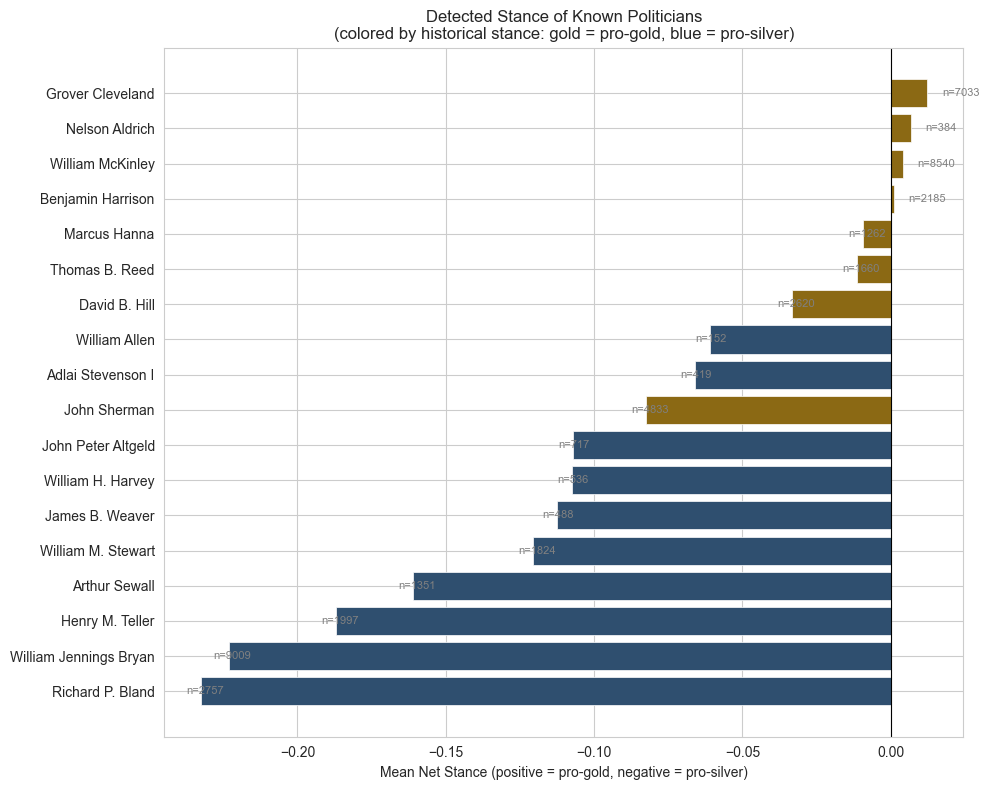

In [4]:
# Visualize: detected stance vs known historical stance
fig, ax = plt.subplots(figsize=(10, 8))

# Filter to politicians with enough mentions
plot_df = person_summary[person_summary["n_articles"] >= 5].copy()

colors = plot_df["known_stance"].map({
    "pro-gold": "#8B6914",
    "pro-silver": "#2F4F6F",
}).fillna("gray")

ax.barh(
    plot_df["entity_name"],
    plot_df["mean_net_stance"],
    color=colors,
    edgecolor="white",
    linewidth=0.5,
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Mean Net Stance (positive = pro-gold, negative = pro-silver)")
ax.set_title("Detected Stance of Known Politicians\n(colored by historical stance: gold = pro-gold, blue = pro-silver)")
ax.invert_yaxis()

# Add article count annotations
for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(
        row["mean_net_stance"] + 0.005 * (1 if row["mean_net_stance"] >= 0 else -1),
        i,
        f"n={row['n_articles']}",
        va="center",
        fontsize=8,
        color="gray",
    )

plt.tight_layout()
plt.savefig("../figures/politician_stances.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# Validation: does the model correctly classify known pro-gold vs pro-silver politicians?
validation = person_summary[person_summary["n_articles"] >= 5].copy()
validation["detected_side"] = np.where(
    validation["mean_net_stance"] > 0, "pro-gold", "pro-silver"
)
validation["correct"] = validation["detected_side"] == validation["known_stance"]

accuracy = validation["correct"].mean()
print(f"\nValidation accuracy (politicians with 5+ mentions): {accuracy:.1%}")
print(f"Correct: {validation['correct'].sum()} / {len(validation)}")
print()

misclassified = validation[~validation["correct"]]
if len(misclassified) > 0:
    print("Misclassified politicians:")
    print(misclassified[["entity_name", "known_stance", "detected_side", "mean_net_stance", "n_articles"]].to_string(index=False))
else:
    print("All known politicians correctly classified!")


Validation accuracy (politicians with 5+ mentions): 77.8%
Correct: 14 / 18

Misclassified politicians:
   entity_name known_stance detected_side  mean_net_stance  n_articles
  Marcus Hanna     pro-gold    pro-silver        -0.009225        1262
Thomas B. Reed     pro-gold    pro-silver        -0.011375        1660
 David B. Hill     pro-gold    pro-silver        -0.033327        2620
  John Sherman     pro-gold    pro-silver        -0.082488        4833


## 7. Residual vs Original Article Stance

Compare the original article-level stance (from notebook 03) with the residual
stance (after removing person-attributed sentences). The difference tells us
how much of an article's measured stance comes from attributed speech vs.
the newspaper's own editorial framing.

In [6]:
# Merge original stances with residual stances
# Use the original article-level stance scores from df
if has_stances:
    comparison = df[["article_id", "pro_gold_score", "pro_silver_score"]].merge(
        residual_with_text[["article_id", "residual_pro_gold", "residual_pro_silver", "residual_net_stance"]],
        on="article_id",
        how="inner",
    )
    comparison["original_net"] = comparison["pro_gold_score"] - comparison["pro_silver_score"]

    print(f"Articles with both original and residual stances: {len(comparison):,}")
    print(f"\nCorrelation between original and residual net stance: {comparison['original_net'].corr(comparison['residual_net_stance']):.3f}")
    print(f"Mean original net stance:  {comparison['original_net'].mean():.4f}")
    print(f"Mean residual net stance:  {comparison['residual_net_stance'].mean():.4f}")
    print(f"Mean shift (residual - original): {(comparison['residual_net_stance'] - comparison['original_net']).mean():.4f}")
else:
    print("Skipping comparison -- no original stance scores available.")

Articles with both original and residual stances: 54,024

Correlation between original and residual net stance: 0.628
Mean original net stance:  -0.1377
Mean residual net stance:  -0.0936
Mean shift (residual - original): 0.0441


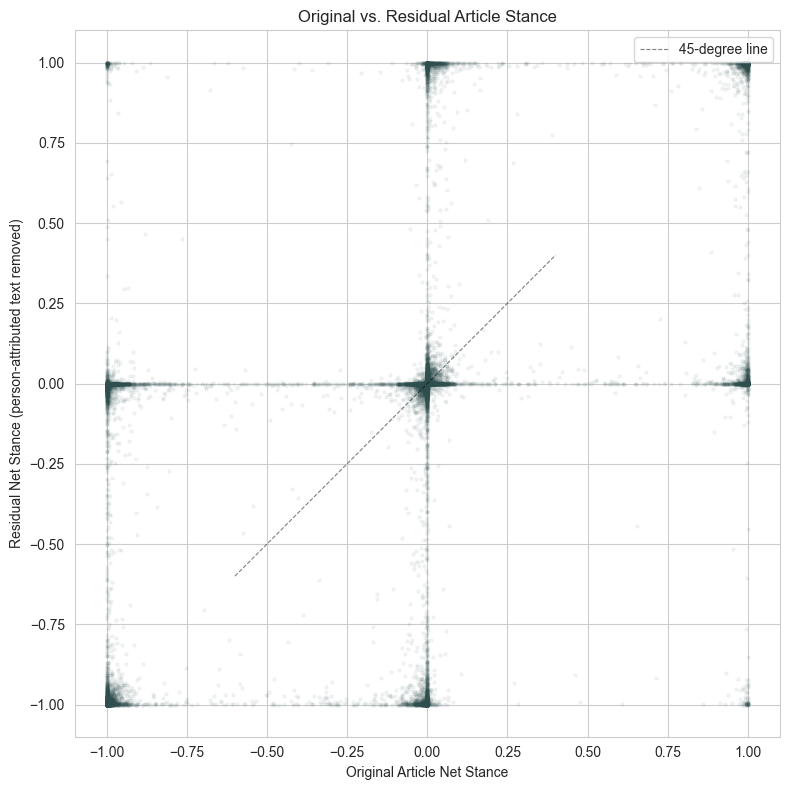

In [7]:
# Scatter plot: original vs residual stance
if has_stances:
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(
        comparison["original_net"],
        comparison["residual_net_stance"],
        alpha=0.05,
        s=5,
        color="#2F4F4F",
    )
    ax.plot([-0.6, 0.4], [-0.6, 0.4], "k--", linewidth=0.8, alpha=0.5, label="45-degree line")
    ax.set_xlabel("Original Article Net Stance")
    ax.set_ylabel("Residual Net Stance (person-attributed text removed)")
    ax.set_title("Original vs. Residual Article Stance")
    ax.legend()
    plt.tight_layout()
    plt.savefig("../figures/original_vs_residual_stance.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Skipping scatter plot -- no original stance scores available.")

## 8. Re-aggregate to Newspaper Level with Residual Stances

Redo the newspaper-level aggregation using the residual stances instead of
the original article stances. This gives us a cleaner measure of newspaper
editorial slant, stripped of attributed speech.

In [8]:
# Compare original vs residual newspaper-level stances
newspaper_original = pd.read_parquet("../data/results/newspaper_stances.parquet")

# Build newspaper_residual if it doesn't already exist
if "newspaper_residual" not in dir():
    residual_with_meta = residual_with_text.merge(
        df[["article_id", "lccn", "newspaper_name"]].drop_duplicates(),
        on="article_id",
        how="left",
    )
    newspaper_residual = (
        residual_with_meta
        .groupby(["lccn", "newspaper_name"])
        .agg(
            n_articles=("article_id", "count"),
            mean_residual_gold=("residual_pro_gold", "mean"),
            mean_residual_silver=("residual_pro_silver", "mean"),
            mean_residual_net=("residual_net_stance", "mean"),
        )
        .reset_index()
        .sort_values("mean_residual_net", ascending=False)
    )

# The original file uses 'net_gold_silver' for the net stance column
net_col = "net_gold_silver" if "net_gold_silver" in newspaper_original.columns else None
if net_col is None:
    # Fallback: compute it
    newspaper_original["net_gold_silver"] = newspaper_original["mean_pro_gold"] - newspaper_original["mean_pro_silver"]
    net_col = "net_gold_silver"

newspaper_compare = newspaper_original[["lccn", "newspaper_name", net_col]].merge(
    newspaper_residual[["lccn", "mean_residual_net"]],
    on="lccn",
    how="inner",
)

print(f"Newspapers in both measures: {len(newspaper_compare):,}")
print(f"Correlation: {newspaper_compare[net_col].corr(newspaper_compare['mean_residual_net']):.3f}")
print(f"Mean original net stance:  {newspaper_compare[net_col].mean():.4f}")
print(f"Mean residual net stance:  {newspaper_compare['mean_residual_net'].mean():.4f}")
print(f"Mean shift (residual - original): {(newspaper_compare['mean_residual_net'] - newspaper_compare[net_col]).mean():.4f}")

Newspapers in both measures: 300
Correlation: 0.813
Mean original net stance:  -0.1561
Mean residual net stance:  -0.1232
Mean shift (residual - original): 0.0329


## 9. Person-Level Analysis: Politicians Across Newspapers

For known politicians with enough mentions, examine how their portrayed
stance varies across newspapers from different regions. Do Western newspapers
portray Bryan as more pro-silver than Northeastern ones?

In [9]:
# Merge entity stances with newspaper geographic info
geo = pd.read_parquet("../data/results/newspaper_stances.parquet")[
    ["lccn", "state_full", "region"]
].drop_duplicates()

entity_with_geo = entity_rows.merge(
    df[["article_id", "lccn"]].drop_duplicates(),
    on="article_id",
    how="left",
).merge(geo, on="lccn", how="left")

# For top politicians, show stance by region
top_politicians = person_summary[person_summary["n_articles"] >= 20]["entity_name"].tolist()

if top_politicians:
    for pol in top_politicians[:5]:
        pol_data = entity_with_geo[entity_with_geo["entity_name"] == pol]
        if pol_data["region"].notna().any():
            regional = pol_data.groupby("region")["entity_net_stance"].agg(["mean", "count"])
            print(f"\n{pol} ({KNOWN_POLITICIANS.get(pol, {}).get('known_stance', '?')}):")
            print(regional.to_string())
else:
    print("No politicians with 20+ mentions. Try lowering the threshold.")


Grover Cleveland (pro-gold):
               mean  count
region                    
Midwest    0.003792   1157
Northeast  0.002389    709
South      0.019214   1801
West       0.017504   2815

Nelson Aldrich (pro-gold):
               mean  count
region                    
Midwest    0.038502     52
Northeast -0.019447     52
South      0.017315     95
West       0.005961    161

William McKinley (pro-gold):
               mean  count
region                    
Midwest    0.003615   1377
Northeast  0.000198   1304
South      0.012005   1440
West       0.004966   3340

Benjamin Harrison (pro-gold):
               mean  count
region                    
Midwest   -0.002704    391
Northeast  0.018204    319
South      0.017671    406
West      -0.011436    900

Marcus Hanna (pro-gold):
               mean  count
region                    
Midwest   -0.043232    163
Northeast -0.017080    176
South     -0.023510    216
West       0.005658    543


## 10. Save Results

In [10]:
import os
os.makedirs("../data/results", exist_ok=True)

# Save entity-level stances
entity_rows.to_parquet("../data/results/entity_stances.parquet", index=False)
print(f"Saved entity stances: {len(entity_rows):,} records")

# Save residual article stances
residual_with_text.to_parquet("../data/results/residual_article_stances.parquet", index=False)
print(f"Saved residual stances: {len(residual_with_text):,} records")

# Save person-level summary
person_summary.to_csv("../data/results/politician_stance_summary.csv", index=False)
print(f"Saved politician summary: {len(person_summary)} politicians")

# Save newspaper-level residual stances
newspaper_residual.to_parquet("../data/results/newspaper_residual_stances.parquet", index=False)
print(f"Saved newspaper residual stances: {len(newspaper_residual):,} newspapers")

print("\nAll results saved.")

Saved entity stances: 338,716 records
Saved residual stances: 54,024 records
Saved politician summary: 18 politicians
Saved newspaper residual stances: 300 newspapers

All results saved.


## 11. Summary Statistics

In [11]:
print("=" * 60)
print("ENTITY-LEVEL STANCE ANALYSIS SUMMARY")
print("=" * 60)
print(f"Total articles processed:           {entity_df['article_id'].nunique():,}")
print(f"Articles with person mentions:       {entity_df[entity_df['entity_name'].notna()]['article_id'].nunique():,}")
print(f"Total entity-article pairs:          {len(entity_rows):,}")
print(f"Known politicians detected:          {entity_rows[entity_rows['is_known_politician']]['entity_name'].nunique()}")
print(f"Unknown persons detected:            {entity_rows[~entity_rows['is_known_politician']]['entity_name'].nunique():,}")
print(f"")
print(f"Entity stance scores:")
print(f"  Mean entity pro-gold:              {entity_rows['entity_pro_gold'].mean():.4f}")
print(f"  Mean entity pro-silver:            {entity_rows['entity_pro_silver'].mean():.4f}")
print(f"")
print(f"Residual stance scores:")
print(f"  Mean residual pro-gold:            {residual_with_text['residual_pro_gold'].mean():.4f}")
print(f"  Mean residual pro-silver:          {residual_with_text['residual_pro_silver'].mean():.4f}")
print(f"")
if len(validation) > 0:
    print(f"Validation (known politicians, 5+ mentions):")
    print(f"  Accuracy:                          {accuracy:.1%}")
print("=" * 60)

ENTITY-LEVEL STANCE ANALYSIS SUMMARY
Total articles processed:           56,355
Articles with person mentions:       50,394
Total entity-article pairs:          338,716
Known politicians detected:          18
Unknown persons detected:            154,893

Entity stance scores:
  Mean entity pro-gold:              0.0486
  Mean entity pro-silver:            0.0880

Residual stance scores:
  Mean residual pro-gold:            0.1290
  Mean residual pro-silver:          0.2226

Validation (known politicians, 5+ mentions):
  Accuracy:                          77.8%


## 12. Residual Stance Geography: Newspaper Editorial Slant

Re-create the regional boxplots and state-level choropleth map using the
**residual** stance scores (person-attributed text removed). These should
better capture actual newspaper editorial positions rather than the stances
of politicians they happen to be reporting on.

In [12]:
# Build state-level residual summary with geo info
newspaper_original = pd.read_parquet("../data/results/newspaper_stances.parquet")
geo_cols = newspaper_original[["lccn", "state_full", "region"]].drop_duplicates()

# Ensure newspaper_residual exists
if "newspaper_residual" not in dir():
    residual_with_meta = residual_with_text.merge(
        df[["article_id", "lccn", "newspaper_name"]].drop_duplicates(),
        on="article_id", how="left",
    )
    newspaper_residual = (
        residual_with_meta.groupby(["lccn", "newspaper_name"])
        .agg(
            n_articles=("article_id", "count"),
            mean_residual_gold=("residual_pro_gold", "mean"),
            mean_residual_silver=("residual_pro_silver", "mean"),
            mean_residual_net=("residual_net_stance", "mean"),
        )
        .reset_index()
    )

newspaper_residual_geo = newspaper_residual.merge(geo_cols, on="lccn", how="left")
print(f"Newspapers with residual stances + geo: {newspaper_residual_geo['region'].notna().sum()}")
print(f"\nResidual stance by region:")
print(newspaper_residual_geo.groupby("region")["mean_residual_net"].agg(["mean", "median", "count"]).to_string())

Newspapers with residual stances + geo: 289

Residual stance by region:
               mean        median  count
region                                  
Midwest   -0.103797 -9.500738e-02     96
Northeast -0.030845  4.788934e-07     25
South     -0.103358 -3.535949e-02     98
West      -0.220878 -1.944346e-01     70


/var/folders/t6/hnwf0b1j59j_hj9x2zffj4x80000gn/T/ipykernel_21913/3665582100.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


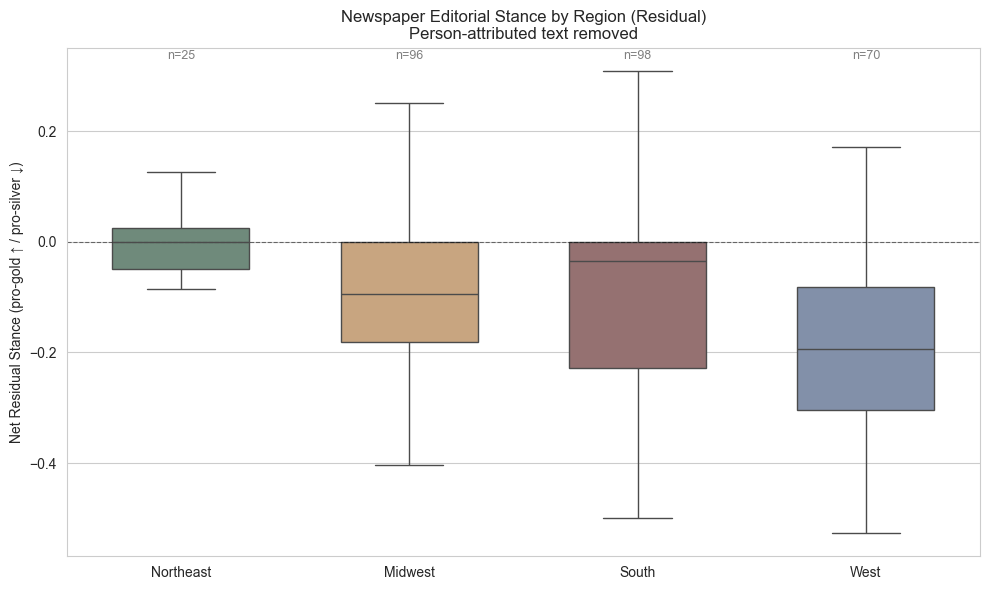

Saved: figures/residual_regional_boxplots.png


In [13]:
# --- Regional Boxplot: Residual Stance ---
region_order = ["Northeast", "Midwest", "South", "West"]
plot_data = newspaper_residual_geo[newspaper_residual_geo["region"].isin(region_order)].copy()

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=plot_data,
    x="region",
    y="mean_residual_net",
    order=region_order,
    palette={"Northeast": "#6B8E7B", "Midwest": "#D4A574", "South": "#9B6B6B", "West": "#7B8EB0"},
    width=0.6,
    showfliers=False,
    ax=ax,
)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_xlabel("")
ax.set_ylabel("Net Residual Stance (pro-gold ↑ / pro-silver ↓)")
ax.set_title("Newspaper Editorial Stance by Region (Residual)\nPerson-attributed text removed")

# Add n= labels
for i, region in enumerate(region_order):
    n = len(plot_data[plot_data["region"] == region])
    ax.text(i, ax.get_ylim()[1] - 0.02, f"n={n}", ha="center", fontsize=9, color="gray")

plt.tight_layout()
plt.savefig("../figures/residual_regional_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/residual_regional_boxplots.png")

Saved: figures/residual_stance_choropleth.html
Saved: figures/residual_stance_choropleth.png


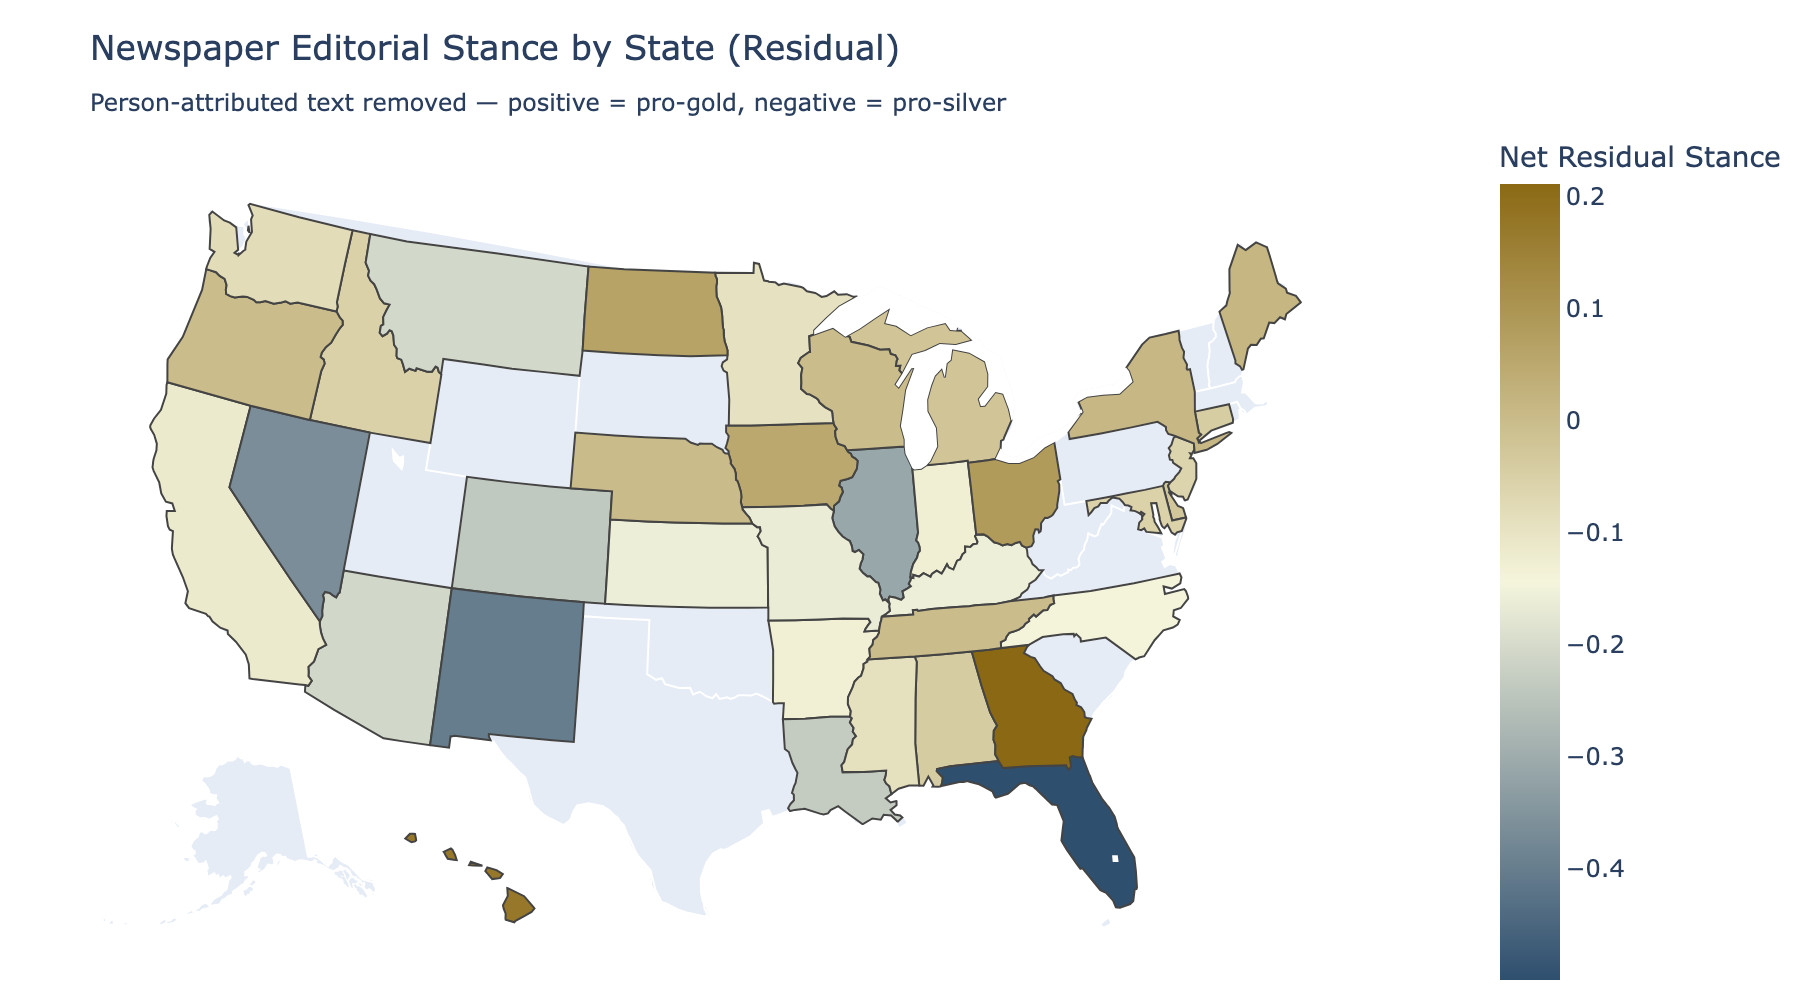

In [14]:
# --- State-Level Choropleth: Residual Stance ---
import plotly.express as px

# Aggregate to state level
state_residual = (
    newspaper_residual_geo[newspaper_residual_geo["state_full"].notna()]
    .groupby("state_full")
    .agg(
        n_newspapers=("lccn", "nunique"),
        mean_residual_net=("mean_residual_net", "mean"),
        mean_residual_gold=("mean_residual_gold", "mean"),
        mean_residual_silver=("mean_residual_silver", "mean"),
    )
    .reset_index()
)

# State name -> abbreviation mapping
state_abbr = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
    "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
    "District Of Columbia": "DC", "Florida": "FL", "Georgia": "GA", "Hawaii": "HI",
    "Idaho": "ID", "Illinois": "IL", "Indiana": "IN", "Iowa": "IA", "Kansas": "KS",
    "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME", "Maryland": "MD",
    "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN", "Mississippi": "MS",
    "Missouri": "MO", "Montana": "MT", "Nebraska": "NE", "Nevada": "NV",
    "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM", "New York": "NY",
    "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK",
    "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI",
    "South Carolina": "SC", "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX",
    "Utah": "UT", "Vermont": "VT", "Virginia": "VA", "Washington": "WA",
    "West Virginia": "WV", "Wisconsin": "WI", "Wyoming": "WY",
}
state_residual["state_abbr"] = state_residual["state_full"].map(state_abbr)

vmin = state_residual["mean_residual_net"].min()
vmax = state_residual["mean_residual_net"].max()

fig = px.choropleth(
    state_residual,
    locations="state_abbr",
    locationmode="USA-states",
    color="mean_residual_net",
    color_continuous_scale=["#2F4F6F", "#F5F5DC", "#8B6914"],
    range_color=[vmin, vmax],
    scope="usa",
    hover_name="state_full",
    hover_data={
        "mean_residual_net": ":.3f",
        "n_newspapers": True,
        "state_abbr": False,
    },
    labels={"mean_residual_net": "Net Residual Stance"},
    title="Newspaper Editorial Stance by State (Residual)<br><sub>Person-attributed text removed — positive = pro-gold, negative = pro-silver</sub>",
)
fig.update_layout(
    geo=dict(bgcolor="rgba(0,0,0,0)"),
    margin=dict(l=0, r=0, t=60, b=0),
)

# Save as HTML and static PNG
fig.write_html("../figures/residual_stance_choropleth.html")
print("Saved: figures/residual_stance_choropleth.html")

try:
    fig.write_image("../figures/residual_stance_choropleth.png", width=900, height=500, scale=2)
    print("Saved: figures/residual_stance_choropleth.png")
    from IPython.display import Image
    display(Image("../figures/residual_stance_choropleth.png"))
except Exception as e:
    print(f"Static PNG export failed ({e}), showing interactive version:")
    fig.show()

In [15]:
# --- Side-by-side comparison: Original vs Residual state summaries ---
state_original = pd.read_csv("../data/results/state_summary.csv")

state_compare = state_original[["state_full", "mean_net", "region"]].merge(
    state_residual[["state_full", "mean_residual_net"]],
    on="state_full",
    how="inner",
) if "mean_net" in state_original.columns else state_original[["state_full", "n_newspapers", "region"]].assign(
    net_gold_silver=state_original["mean_pro_gold"] - state_original["mean_pro_silver"]
).rename(columns={"net_gold_silver": "mean_net"})[["state_full", "mean_net", "region"]].merge(
    state_residual[["state_full", "mean_residual_net"]],
    on="state_full",
    how="inner",
)

state_compare["shift"] = state_compare["mean_residual_net"] - state_compare["mean_net"]

print("State-level comparison: Original vs Residual net stance")
print(f"{'State':<22} {'Original':>10} {'Residual':>10} {'Shift':>8} {'Region'}")
print("-" * 65)
for _, row in state_compare.sort_values("shift", ascending=False).iterrows():
    print(f"{row['state_full']:<22} {row['mean_net']:>10.3f} {row['mean_residual_net']:>10.3f} {row['shift']:>+8.3f} {row.get('region', '')}")

print(f"\nMean shift across states: {state_compare['shift'].mean():+.4f}")
print(f"States that shifted toward gold: {(state_compare['shift'] > 0).sum()}")
print(f"States that shifted toward silver: {(state_compare['shift'] < 0).sum()}")

State-level comparison: Original vs Residual net stance
State                    Original   Residual    Shift Region
-----------------------------------------------------------------
Georgia                    -0.142      0.211   +0.353 South
Hawaii                     -0.088      0.172   +0.260 West
Idaho                      -0.182     -0.053   +0.128 West
Montana                    -0.333     -0.205   +0.128 West
Arizona                    -0.305     -0.207   +0.098 West
North Dakota               -0.027      0.065   +0.091 Midwest
Kansas                     -0.246     -0.160   +0.086 Midwest
Missouri                   -0.250     -0.165   +0.085 Midwest
North Carolina             -0.223     -0.146   +0.077 South
District Of Columbia       -0.117     -0.053   +0.064 nan
Michigan                   -0.086     -0.023   +0.064 Midwest
California                 -0.165     -0.116   +0.050 West
Arkansas                   -0.177     -0.132   +0.045 South
Oregon                     -0.037   